In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Data Loading

In [2]:
try:
    df = pd.read_csv('/kaggle/input/datasets/tanmay23f1/yield-data/production_unified_imputed.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The file '/content/production_unified_imputed.csv' was not found. Please ensure it's uploaded correctly.")

    df = None


if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    print("\nDataFrame Info:")
    df.info()

Dataset loaded successfully.

First 5 rows of the dataset:


,crop,year,state,district,season,area,production,yield,data_source,annual_rainfall,fertilizer,pesticide,crop_type,area_unit,production_unit,yield_unit
0,wheat,2014,uttar pradesh,ghaziabad,Rabi,26619.0,86645.0,3.255,area_production,1247.199725,1.248187e+06,2438.165184,cereals,Hectare,Tonnes,Tonnes/Hectare
1,urad,2014,uttar pradesh,ghaziabad,Summer,22.0,12.0,0.545,area_production,1247.339375,1.235179e+06,2420.293698,pulses,Hectare,Tonnes,Tonnes/Hectare
2,urad,2014,uttar pradesh,ghaziabad,Kharif,19.0,10.0,0.526,area_production,1247.339396,1.235177e+06,2420.290923,pulses,Hectare,Tonnes,Tonnes/Hectare
3,sugarcane,2014,uttar pradesh,ghaziabad,Kharif,11136.0,750076.0,67.356,area_production,1247.223783,1.245441e+06,2437.372883,sugar,Hectare,Tonnes,Tonnes/Hectare
4,rice,2014,uttar pradesh,ghaziabad,Kharif,8650.0,23727.0,2.743,area_production,1247.278389,1.240637e+06,2428.557661,cereals,Hectare,Tonnes,Tonnes/Hectare



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440962 entries, 0 to 440961
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   crop             440962 non-null  object 
 1   year             440962 non-null  int64  
 2   state            440962 non-null  object 
 3   district         440962 non-null  object 
 4   season           440962 non-null  object 
 5   area             440962 non-null  float64
 6   production       440962 non-null  float64
 7   yield            440962 non-null  float64
 8   data_source      440962 non-null  object 
 9   annual_rainfall  440962 non-null  float64
 10  fertilizer       440962 non-null  float64
 11  pesticide        440962 non-null  float64
 12  crop_type        440962 non-null  object 
 13  area_unit        440962 non-null  object 
 14  production_unit  440962 non-null  object 
 15  yield_unit       440962 non-null  object 
dtypes: float64(6), int64(

# 2. Descriptive Statistics

In [3]:
# 1. Descriptive Statistics for Numerical Features
print("\nDescriptive Statistics for Numerical Features:")
display(df.describe())


Descriptive Statistics for Numerical Features:


,year,area,production,yield,annual_rainfall,fertilizer,pesticide
count,440962.000000,4.409620e+05,4.409620e+05,440962.000000,440962.000000,4.409620e+05,4.409620e+05
mean,2010.807566,1.866081e+04,7.770790e+04,4.638478,1256.091552,2.256646e+06,4.495505e+03
std,7.649435,1.647833e+05,1.269888e+06,23.275370,177.092480,2.061205e+07,4.607747e+04
min,1997.000000,0.000000e+00,-5.909608e+04,-2.141256,301.300000,-9.510131e+07,-9.337094e+04
25%,2004.000000,5.500000e+01,5.600000e+01,0.573000,1247.411429,1.230567e+06,2.416931e+03
50%,2011.000000,4.850000e+02,6.180000e+02,1.057000,1247.626396,1.234196e+06,2.420560e+03
75%,2017.000000,4.182000e+03,6.960000e+03,2.595000,1247.785330,1.238961e+06,2.425469e+03
max,2024.000000,5.080810e+07,1.796982e+08,9801.000000,6552.700000,4.835407e+09,1.575051e+07


In [4]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 2. Distribution of Numerical Features
# print("\nDistribution of Numerical Features:")

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# print(numerical_cols)
# # Adjust subplot grid based on the number of numerical columns
# num_numerical_cols = len(numerical_cols)
# rows = (num_numerical_cols + 2) // 3 # Roughly 3 columns per row
# cols = min(num_numerical_cols, 3)

# plt.figure(figsize=(5 * cols, 4 * rows))
# for i, col in enumerate(numerical_cols):
#     plt.subplot(rows, cols, i + 1)
#     sns.histplot(df[col], kde=True)
#     plt.title(f'Distribution of {col}')
# plt.tight_layout()
# plt.show()


Distribution of Categorical Features (Top 10):


/tmp/ipykernel_126/693592998.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[:10], palette='viridis')
/tmp/ipykernel_126/693592998.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[:10], palette='viridis')
/tmp/ipykernel_126/693592998.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[:10], palette='viridis')
/tmp/ipykernel_126/693592998.py:7: FutureWarning: 

Passing `palette` without assigni

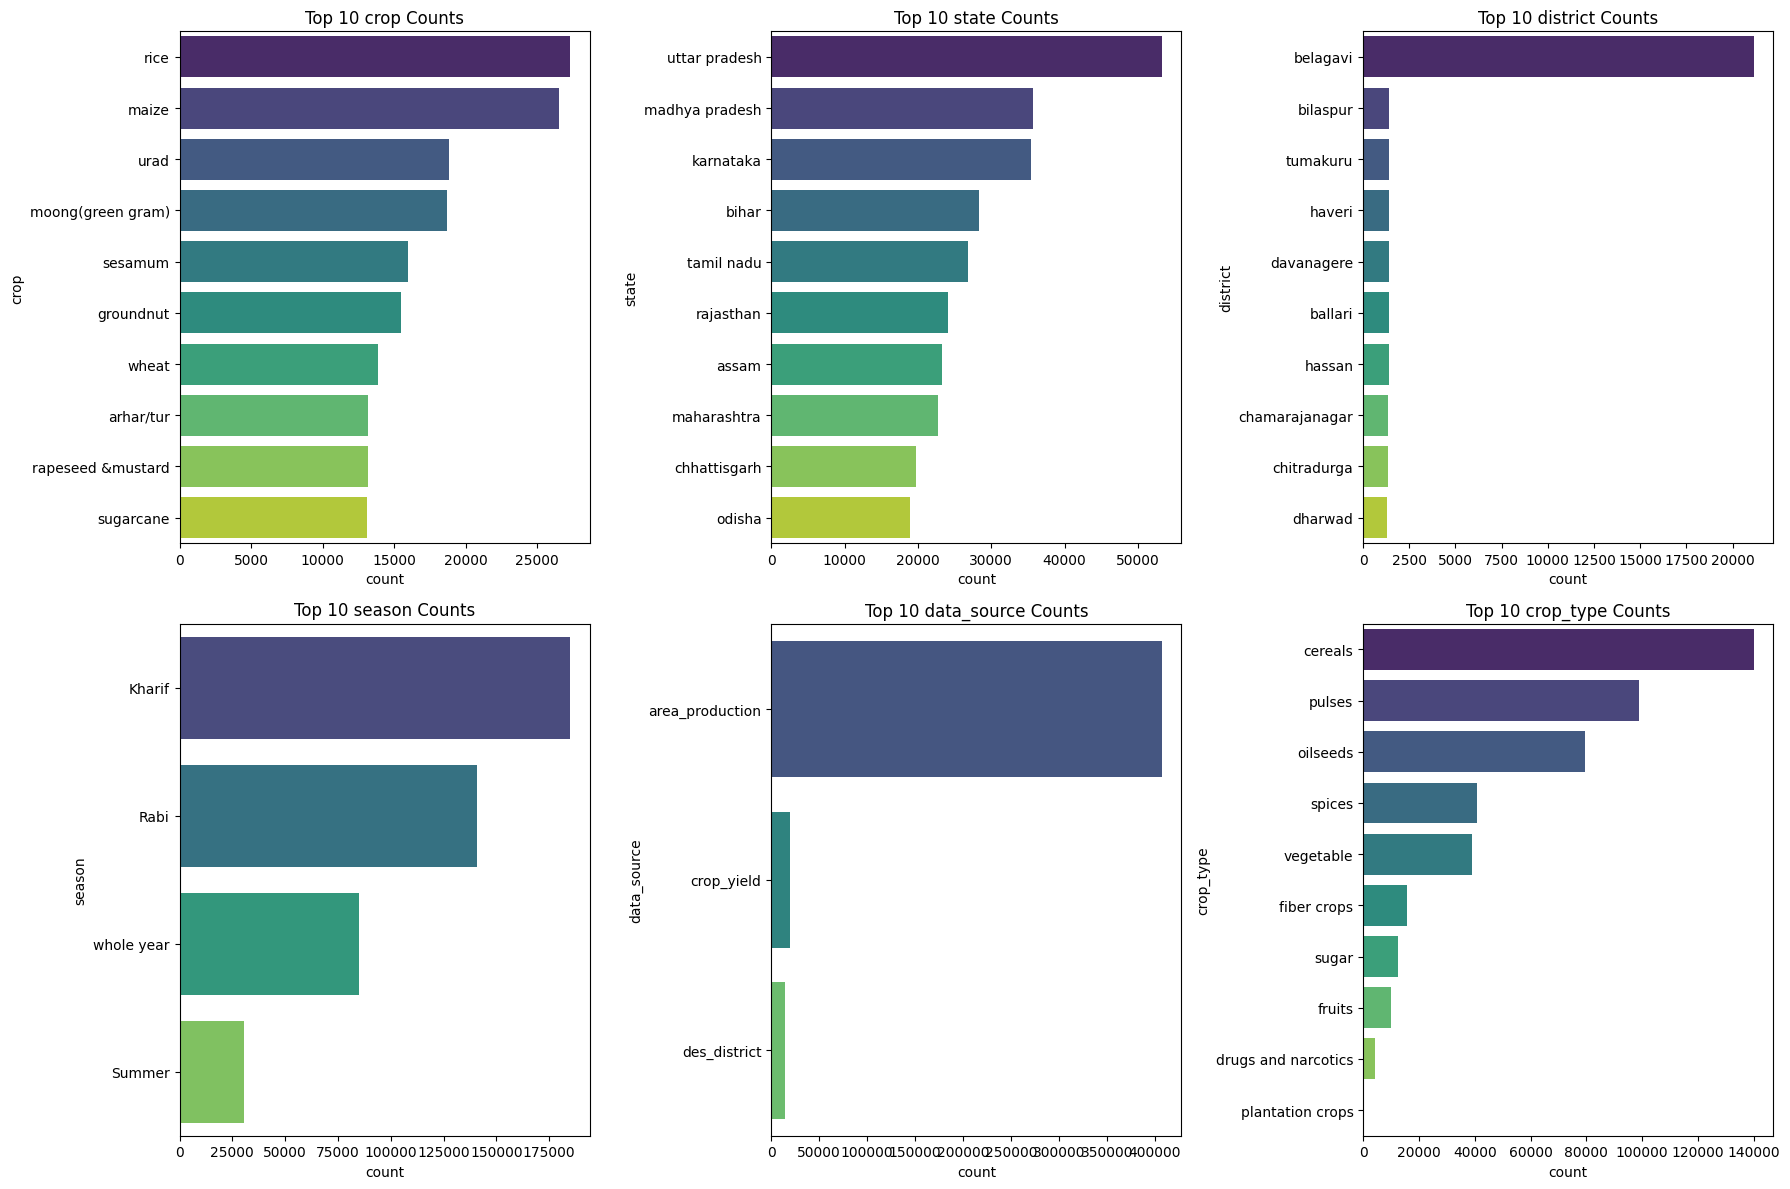

In [5]:
# 3. Count Plots for Categorical Features (Top N categories)
import seaborn as sns
print("\nDistribution of Categorical Features (Top 10):")
plt.figure(figsize=(18, 12))
for i, col in enumerate(['crop', 'state', 'district', 'season', 'data_source', 'crop_type']):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10], palette='viridis')
    plt.title(f'Top 10 {col} Counts')
plt.tight_layout()
plt.show()


Correlation Matrix for Numerical Features:


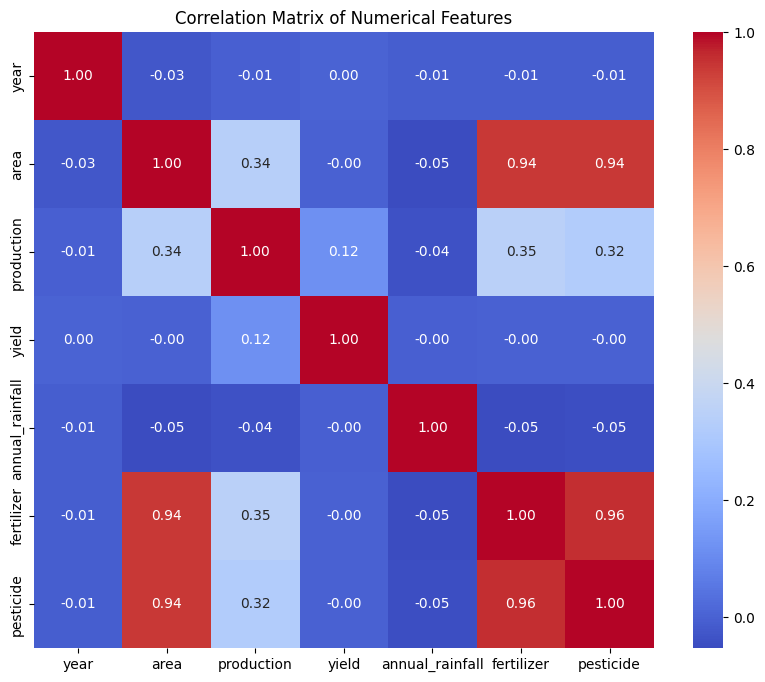

In [6]:
# 4. Correlation Matrix for Numerical Features
print("\nCorrelation Matrix for Numerical Features:")
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Target Variable (Yield) Distribution:


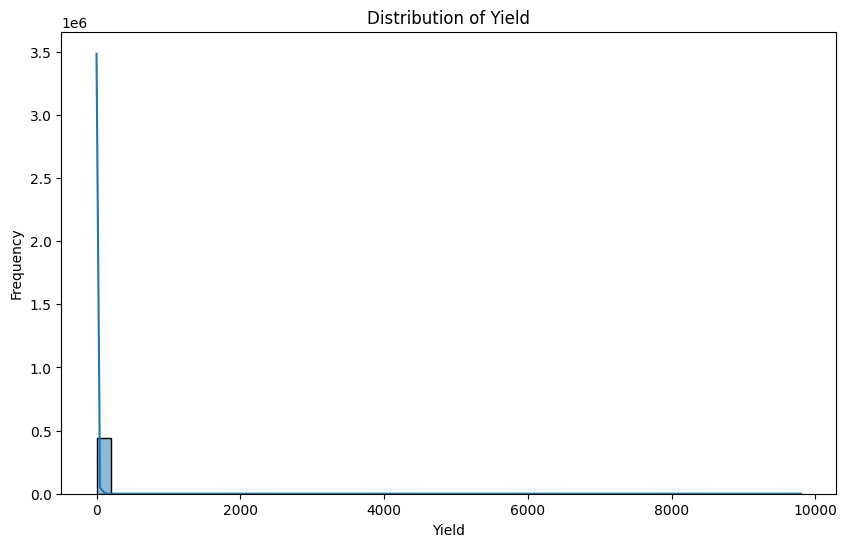

Skewness of Yield: 198.6033


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Target Variable Distribution (Yield) and Skewness
print("\nTarget Variable (Yield) Distribution:")
plt.figure(figsize=(10, 6))
sns.histplot(df['yield'], kde=True, bins=50)
plt.title('Distribution of Yield')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness of Yield: {df['yield'].skew():.4f}")

In [8]:
### 2.3 Missing Values and Unique Counts

In [9]:
# 7. Unique Counts for 'crop' and 'state'
print("\nUnique Crop Counts:")
display(df['crop'].value_counts().head(10))

print("\nUnique State Counts:")
display(df['state'].value_counts().head(10))


Unique Crop Counts:


crop
rice                 27304
maize                26549
urad                 18824
moong(green gram)    18689
sesamum              15971
groundnut            15471
wheat                13901
arhar/tur            13166
rapeseed &mustard    13163
sugarcane            13084
Name: count, dtype: int64


Unique State Counts:


state
uttar pradesh     53266
madhya pradesh    35681
karnataka         35469
bihar             28353
tamil nadu        26812
rajasthan         24135
assam             23286
maharashtra       22671
chhattisgarh      19774
odisha            18912
Name: count, dtype: int64


Outlier Analysis for Numerical Features:


/tmp/ipykernel_126/2279532930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='plasma')
/tmp/ipykernel_126/2279532930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='plasma')
/tmp/ipykernel_126/2279532930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='plasma')
/tmp/ipykernel_126/2279532930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

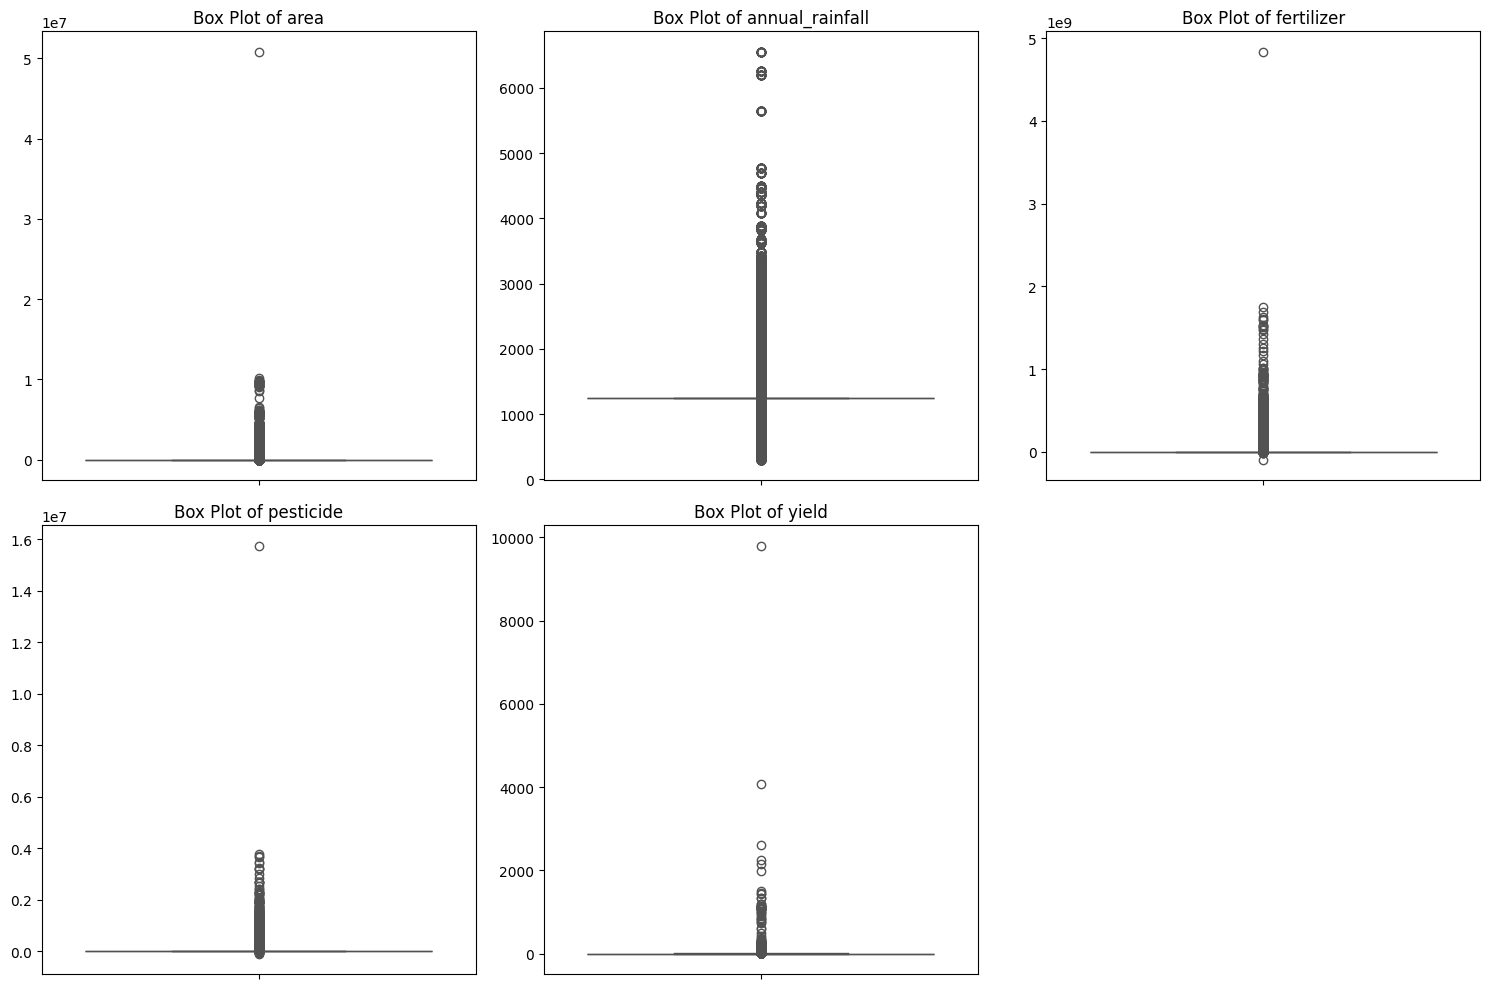

In [10]:
# 8. Outlier Analysis for Numerical Features (Box Plots)
print("\nOutlier Analysis for Numerical Features:")

numerical_cols_for_boxplots = ['area', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_boxplots):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col], palette='plasma')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

# 3. Data Preprocessing

In [11]:
import pandas as pd
import numpy as np

print(f"Starting rows: {len(df)}")

# -----------------------------------------------------------------
# 1. Drop exact duplicates
# -----------------------------------------------------------------
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows -> {len(df)}")

# -----------------------------------------------------------------
# 2. Remove physically impossible rows
#    - production, yield, fertilizer, pesticide cannot be negative
#    - area must be > 0 (yield/production undefined otherwise, and these
#      rows are imputation artifacts anyway)
# -----------------------------------------------------------------
before = len(df)
mask_valid = (
    (df['area'] > 0) &
    (df['production'] >= 0) &
    (df['yield'] >= 0) &
    (df['fertilizer'] >= 0) &
    (df['pesticide'] >= 0)
)
df = df[mask_valid].copy()
print(f"Dropped {before - len(df)} physically impossible rows -> {len(df)}")

# -----------------------------------------------------------------
# 3. Recompute yield directly from production/area.
#    The stored 'yield' column is confirmed to be a near-exact derived
#    quantity (median abs diff ~0.0002 vs production/area) for the vast
#    majority of rows, with ~5% noisy/inconsistent exceptions. Recomputing
#    makes the target internally consistent.
# -----------------------------------------------------------------
df['yield_recalculated'] = df['production'] / df['area']
diff = (df['yield_recalculated'] - df['yield']).abs()
inconsistent = (diff > 0.01).sum()
print(f"Rows where stored yield disagreed with production/area by >0.01: {inconsistent} ({inconsistent/len(df):.2%})")

df['yield'] = df['yield_recalculated']
df = df.drop(columns=['yield_recalculated'])

# -----------------------------------------------------------------
# 4. Outlier capping — PER CROP_TYPE, since sane yield ranges differ
#    wildly by crop (e.g. sugar ~55-60 t/ha typical vs pulses ~0.6-1
#    t/ha typical). A global cutoff would wrongly remove legitimate
#    sugar/fruit yields or miss pulses/oilseeds outliers.
# -----------------------------------------------------------------
before = len(df)
cap_per_group = df.groupby('crop_type')['yield'].transform(lambda s: s.quantile(0.99))
df = df[df['yield'] <= cap_per_group].copy()
print(f"Dropped {before - len(df)} extreme yield outliers (>99th pct within crop_type) -> {len(df)}")

# -----------------------------------------------------------------
# 5. Resolve target leakage: production and area together
#    mathematically determine yield (yield = production/area, enforced
#    in step 3). Using both as features would let the model just learn
#    division instead of real agricultural relationships.
#
#    Decision: keep 'area' (known ahead of harvest) as a feature,
#    DROP 'production' (only known after harvest, directly encodes
#    the answer).
# -----------------------------------------------------------------
LEAKY_COLS = ['production']

# -----------------------------------------------------------------
# 6. Drop unit columns — confirmed constant across all rows (all
#    Hectare / Tonnes / Tonnes-per-Hectare), so they carry zero signal.
# -----------------------------------------------------------------
UNIT_COLS = ['area_unit', 'production_unit', 'yield_unit']

drop_cols = [c for c in LEAKY_COLS + UNIT_COLS if c in df.columns]
df = df.drop(columns=drop_cols)

print(f"\nFinal cleaned dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Starting rows: 440962
Dropped 17 exact duplicate rows -> 440945
Dropped 9830 physically impossible rows -> 431115
Rows where stored yield disagreed with production/area by >0.01: 22105 (5.13%)
Dropped 4312 extreme yield outliers (>99th pct within crop_type) -> 426803

Final cleaned dataset shape: (426803, 12)
Columns: ['crop', 'year', 'state', 'district', 'season', 'area', 'yield', 'data_source', 'annual_rainfall', 'fertilizer', 'pesticide', 'crop_type']


In [12]:
categorical_features = ['crop', 'state', 'district', 'season', 'data_source', 'crop_type']
numerical_features = ['year', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']
target = 'yield'
df_model = df.copy()

print(f"\ndf_model ready: {df_model.shape}")

df_model.to_csv('production_unified_imputed_cleaned.csv', index=False)


df_model ready: (426803, 12)


# 4. Train/Test Split

In [13]:
X = df_model[categorical_features + numerical_features]
y = df_model[target]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
X_test


Train: (308364, 11), Val: (54418, 11), Test: (64021, 11)


,crop,state,district,season,data_source,crop_type,year,area,annual_rainfall,fertilizer,pesticide
435001,other rabi pulses,jammu and kashmir,belagavi,Rabi,crop_yield,cereals,2006,52.00,1786.500000,6.640920e+03,11.440000
236856,gram,maharashtra,latur,Rabi,area_production,pulses,2003,40200.00,1247.564101,1.239466e+06,2426.593234
267795,urad,telangana,narayanpet,Rabi,area_production,pulses,2022,39.00,1247.799214,1.227219e+06,2412.724483
187308,linseed,jharkhand,simdega,Rabi,area_production,oilseeds,2019,3467.00,1247.775948,1.232316e+06,2418.731956
354541,peas & beans (pulses),madhya pradesh,chhindwara,whole year,area_production,pulses,2009,4569.00,1247.458567,1.241085e+06,2425.501332
...,...,...,...,...,...,...,...,...,...,...,...
162473,gram,assam,baksa,Rabi,area_production,pulses,2018,282.00,1248.041295,1.231345e+06,2416.722901
372621,jute,odisha,keonjhar,Kharif,area_production,fiber crops,2003,646.00,1247.554759,1.229501e+06,2417.164363
218650,groundnut,chhattisgarh,surguja,Kharif,area_production,oilseeds,2000,7802.00,1247.626942,1.234811e+06,2429.892924
381397,coriander,bihar,patna,whole year,area_production,spices,2004,87.00,1247.887411,1.230933e+06,2414.907391



## 4.1 CATEGORICAL DTYPE HANDLING (native XGBoost support)

In [14]:

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    cats = X_train[col].cat.categories
    X_val[col] = X_val[col].astype('category').cat.set_categories(cats)
    X_test[col] = X_test[col].astype('category').cat.set_categories(cats)

# Check for unseen categories in val/test that became NaN after alignment
for col in categorical_features:
    n_val_nan = X_val[col].isna().sum()
    n_test_nan = X_test[col].isna().sum()
    if n_val_nan or n_test_nan:
        print(f"Warning: {col} has {n_val_nan} unseen categories in val, {n_test_nan} in test")


# 5. PyTorch Regressor 

## 5.1 Preparing Data for PyTorch

To use PyTorch, need to convert our numpy arrays (from pandas DataFrames/Series) into PyTorch tensors. We'll also create `DataLoader` objects for efficient batch processing during training.

In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# One-hot encode categorical features for PyTorch
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns - crucial for consistent feature sets after one-hot encoding
# especially if a category exists in train but not in val/test or vice-versa
train_cols = X_train_encoded.columns
X_val_encoded = X_val_encoded.reindex(columns=train_cols, fill_value=0)
X_test_encoded = X_test_encoded.reindex(columns=train_cols, fill_value=0)


X_train_np = X_train_encoded.values.astype(np.float32)
X_test_np = X_test_encoded.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

X_train_tensor = torch.tensor(X_train_np)
X_test_tensor = torch.tensor(X_test_np)
y_train_tensor = torch.tensor(y_train_np).unsqueeze(1)
y_test_tensor = torch.tensor(y_test_np).unsqueeze(1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

X_train_tensor shape: torch.Size([308364, 923])
y_train_tensor shape: torch.Size([308364, 1])

Number of training batches: 4819
Number of testing batches: 1001


## 5.2 Define PyTorch Model Architecture

 Defining a simple Multi-Layer Perceptron (MLP) using PyTorch's `nn.Module` for our yield prediction task. Since this is a regression problem, the output layer will have a single neuron without an activation function, suitable for predicting continuous values.

In [16]:
import torch.nn as nn
import torch.optim as optim

class YieldPredictor(nn.Module):
    def __init__(self, input_size):
        super(YieldPredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

input_size = X_train_tensor.shape[1]
torch_model = YieldPredictor(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.001)

print(torch_model)
print(f"\nLoss function: {criterion}")
print(f"Optimizer: {optimizer}")

YieldPredictor(
  (fc1): Linear(in_features=923, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 5.3 Train the PyTorch Model

Training the defined `YieldPredictor` model using our `train_loader`. We'll monitor the training loss and evaluate the model's performance on the test set after training.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_model.to(device)

print(f"Using device: {device}")

num_epochs = 10

for epoch in range(num_epochs):
    torch_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = torch_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

print("\nTraining finished!")

Using device: cpu
Epoch 1/10, Loss: 218897295.9436
Epoch 2/10, Loss: 2429499.9909
Epoch 3/10, Loss: 17087.2293
Epoch 4/10, Loss: 4639.2293
Epoch 5/10, Loss: 151.8531
Epoch 6/10, Loss: 133.2478
Epoch 7/10, Loss: 132.1697
Epoch 8/10, Loss: 132.3247
Epoch 9/10, Loss: 134.1517
Epoch 10/10, Loss: 131.9795

Training finished!


## 5.4. Evaluate the PyTorch Model
After training, we will evaluate the model's performance on the unseen test dataset using metrics like Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

In [18]:
torch_model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = torch_model(inputs)
        predictions.extend(outputs.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

predictions = np.array(predictions).flatten()
true_labels = np.array(true_labels).flatten()

mse = mean_squared_error(true_labels, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(true_labels, predictions)

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")


Model Evaluation on Test Set:
Mean Squared Error (MSE): 135.8728
Root Mean Squared Error (RMSE): 11.6564
R-squared (R2): -0.0000


# 6. Yield Prediction with Gradient Boosting (Model Traing + Hyper Param Tuning)

## 6.1 XGBoost

In [19]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    enable_categorical=True,   # <-- this fixes the ValueError
    device='cpu'             # keep commented unless GPU runtime confirmed
)

print("Training XGBoost Regressor...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)
print("XGBoost training complete. Evaluating on test set...")

xgb_predictions = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, xgb_predictions)

print(f"\nXGBoost Model Evaluation on Test Set:")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

Training XGBoost Regressor...
[0]	validation_0-rmse:10.97866	validation_1-rmse:10.98578
[100]	validation_0-rmse:2.26875	validation_1-rmse:2.85489
[200]	validation_0-rmse:1.95883	validation_1-rmse:2.72765
[300]	validation_0-rmse:1.78402	validation_1-rmse:2.69083
[400]	validation_0-rmse:1.64232	validation_1-rmse:2.66142
[500]	validation_0-rmse:1.52726	validation_1-rmse:2.63141
[600]	validation_0-rmse:1.43651	validation_1-rmse:2.60930
[700]	validation_0-rmse:1.36263	validation_1-rmse:2.59333
[800]	validation_0-rmse:1.29432	validation_1-rmse:2.57860
[900]	validation_0-rmse:1.23732	validation_1-rmse:2.56884
[999]	validation_0-rmse:1.18481	validation_1-rmse:2.55503
XGBoost training complete. Evaluating on test set...

XGBoost Model Evaluation on Test Set:
Mean Squared Error (MSE): 6.0866
Root Mean Squared Error (RMSE): 2.4671
R-squared (R2): 0.9552


In [20]:
from sklearn.model_selection import RandomizedSearchCV, KFold
import scipy.stats as stats

print("Starting Hyperparameter Tuning for XGBoost using RandomizedSearchCV...")

param_dist = {
    'n_estimators': stats.randint(100, 500),      # capped lower — final n_estimators tuned separately with early stopping
    'learning_rate': stats.loguniform(0.01, 0.3),
    'max_depth': stats.randint(3, 10),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'gamma': stats.uniform(0, 0.5),
    'reg_alpha': stats.loguniform(1e-5, 1),
    'reg_lambda': stats.loguniform(1e-5, 1)
}

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=1,
        tree_method='hist',
        enable_categorical=True,   # <-- fixes the dtype error
        device='cpu'               # CPU is simpler/safer given district's 749 categories; switch to 'cuda' only if confirmed faster
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=cv_strategy,
    verbose=100,
    random_state=42,
    n_jobs=-1                      # parallelize across CV folds/iterations on CPU
)

random_search.fit(X_train, y_train)

print("\nHyperparameter tuning complete.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation MSE: {-random_search.best_score_:.4f}")

best_xgb_model = random_search.best_estimator_
best_xgb_predictions = best_xgb_model.predict(X_test)

mse_best_xgb = mean_squared_error(y_test, best_xgb_predictions)
rmse_best_xgb = np.sqrt(mse_best_xgb)
r2_best_xgb = r2_score(y_test, best_xgb_predictions)

print(f"\nBest Tuned XGBoost Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_best_xgb:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_xgb:.4f}")
print(f"  R-squared (R2): {r2_best_xgb:.4f}")

Starting Hyperparameter Tuning for XGBoost using RandomizedSearchCV...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 3/3; 1/20] START colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.1205712628744377, max_depth=7, n_estimators=120, reg_alpha=6.0268891286825045e-05, reg_lambda=6.025215736203858e-05, subsample=0.6232334448672797
[CV 3/3; 1/20] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.1205712628744377, max_depth=7, n_estimators=120, reg_alpha=6.0268891286825045e-05, reg_lambda=6.025215736203858e-05, subsample=0.6232334448672797;, score=-7.567 total time=  16.2s
[CV 1/3; 3/20] START colsample_bytree=0.6727299868828402, gamma=0.09170225492671691, learning_rate=0.028145092716060652, max_depth=8, n_estimators=352, reg_alpha=0.0014445251022763056, reg_lambda=0.0002858549394196192, subsample=0.8447411578889518
[CV 1/3; 3/20] END colsample_bytree=0.6727299868828402, gamma=0.09170225492671691, learning_rate=0

## 6.2 LightGBM Model

LightGBM is popular gradient boosting framework that uses tree-based learning algorithms. It's known for its speed and efficiency, especially with large datasets, and also supports GPU acceleration.

In [21]:
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader

print("Training LightGBM Regressor...")

lgbm_model = lgb.LGBMRegressor(
    objective='regression', # MAE objective, often more robust to outliers
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1, # No limit on tree depth
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    device='cpu' if torch.cuda.is_available() else 'cpu' # Use GPU if available
)

lgbm_model.fit(X_train, y_train)

print("LightGBM training complete. Evaluating on test set...")

lgbm_predictions = lgbm_model.predict(X_test)

mse_lgbm = mean_squared_error(y_test, lgbm_predictions)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test, lgbm_predictions)

print(f"\nLightGBM Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_lgbm:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lgbm:.4f}")
print(f"  R-squared (R2): {r2_lgbm:.4f}")

Training LightGBM Regressor...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 308364, number of used features: 11
[LightGBM] [Info] Start training from score 4.320490
LightGBM training complete. Evaluating on test set...

LightGBM Model Evaluation on Test Set:
  Mean Squared Error (MSE): 6.5473
  Root Mean Squared Error (RMSE): 2.5588
  R-squared (R2): 0.9518


In [22]:
from sklearn.model_selection import RandomizedSearchCV, KFold
import scipy.stats as stats
import lightgbm as lgb

print("LightGBM with aligned objective/scoring...")

lgbm_param_dist = {
    'n_estimators': stats.randint(100, 500),
    'learning_rate': stats.loguniform(0.01, 0.3),
    'num_leaves': stats.randint(20, 100),      # widened — previous search may have hit the ceiling at 60
    'max_depth': stats.randint(5, 15),
    'min_child_samples': stats.randint(10, 50),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'reg_alpha': stats.loguniform(1e-5, 1),
    'reg_lambda': stats.loguniform(1e-5, 1),
}

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

lgbm_random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(
        objective='regression',
        random_state=42,
        n_jobs=1,
        device='cpu',
        verbosity=-1
    ),
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

lgbm_random_search.fit(X_train, y_train)

print("\nLightGBM re-tuning complete.")
print(f"Best parameters found for LightGBM: {lgbm_random_search.best_params_}")
print(f"Best cross-validation MSE for LightGBM: {-lgbm_random_search.best_score_:.4f}")

best_lgbm_model = lgbm_random_search.best_estimator_
best_lgbm_predictions = best_lgbm_model.predict(X_test)

mse_best_lgbm = mean_squared_error(y_test, best_lgbm_predictions)
rmse_best_lgbm = np.sqrt(mse_best_lgbm)
r2_best_lgbm = r2_score(y_test, best_lgbm_predictions)

print(f"\nBest Tuned LightGBM Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_best_lgbm:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_lgbm:.4f}")
print(f"  R-squared (R2): {r2_best_lgbm:.4f}")

LightGBM with aligned objective/scoring...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

LightGBM re-tuning complete.
Best parameters found for LightGBM: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.2536999076681772), 'max_depth': 12, 'min_child_samples': 30, 'n_estimators': 202, 'num_leaves': 94, 'reg_alpha': np.float64(0.0019780827689353767), 'reg_lambda': np.float64(0.0004661686413912767), 'subsample': np.float64(0.6571467271687763)}
Best cross-validation MSE for LightGBM: 6.3293

Best Tuned LightGBM Model Evaluation on Test Set:
  Mean Squared Error (MSE): 5.8139
  Root Mean Squared Error (RMSE): 2.4112
  R-squared (R2): 0.9572


## 6.3 CatBoost Model

CatBoost is another powerful open-source gradient boosting library that excels at handling categorical features automatically. It also offers GPU support for faster training.

In [23]:
!pip install catboost

In [24]:
from catboost import CatBoostRegressor

print("Training CatBoost Regressor...")

# CatBoost requires cat_features as strings, not pandas 'category' dtype —
# category-dtype NaN (e.g. from unseen categories after cat.set_categories in
# cell 8) isn't accepted. Build separate string-typed copies just for CatBoost.
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str).replace('nan', 'missing')
    X_val_cb[col]   = X_val_cb[col].astype(str).replace('nan', 'missing')
    X_test_cb[col]  = X_test_cb[col].astype(str).replace('nan', 'missing')

cat_features_indices = [X_train_cb.columns.get_loc(col) for col in categorical_features if col in X_train_cb.columns]

catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    task_type='CPU'
)

catboost_model.fit(
    X_train_cb, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_val_cb, y_val),
    early_stopping_rounds=50
)

print("CatBoost training complete. Evaluating on test set...")
catboost_predictions = catboost_model.predict(X_test_cb)

mse_catboost = mean_squared_error(y_test, catboost_predictions)
rmse_catboost = np.sqrt(mse_catboost)
r2_catboost = r2_score(y_test, catboost_predictions)

print(f"\nCatBoost Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_catboost:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_catboost:.4f}")
print(f"  R-squared (R2): {r2_catboost:.4f}")

Training CatBoost Regressor...
0:	learn: 11.0257198	test: 11.0224075	best: 11.0224075 (0)	total: 418ms	remaining: 6m 57s
100:	learn: 3.7043268	test: 3.6834500	best: 3.6834500 (100)	total: 21.5s	remaining: 3m 11s
200:	learn: 3.3860252	test: 3.4165148	best: 3.4165148 (200)	total: 40.9s	remaining: 2m 42s
300:	learn: 3.2297294	test: 3.2933014	best: 3.2933014 (300)	total: 1m	remaining: 2m 20s
400:	learn: 3.1100895	test: 3.2018751	best: 3.2018751 (400)	total: 1m 21s	remaining: 2m 2s
500:	learn: 3.0016729	test: 3.1224944	best: 3.1224944 (500)	total: 1m 43s	remaining: 1m 43s
600:	learn: 2.9228093	test: 3.0712680	best: 3.0712680 (600)	total: 2m 5s	remaining: 1m 23s
700:	learn: 2.8645603	test: 3.0338964	best: 3.0338964 (700)	total: 2m 28s	remaining: 1m 3s
800:	learn: 2.8091923	test: 2.9974843	best: 2.9974843 (800)	total: 2m 51s	remaining: 42.6s
900:	learn: 2.7584415	test: 2.9657925	best: 2.9657925 (900)	total: 3m 15s	remaining: 21.5s
999:	learn: 2.7151990	test: 2.9352555	best: 2.9352555 (999)	to

In [25]:
from sklearn.model_selection import RandomizedSearchCV, KFold
import scipy.stats as stats
from catboost import CatBoostRegressor

print("Starting Hyperparameter Tuning for CatBoost using RandomizedSearchCV...")

# CatBoost needs string-typed cat features with no NaN — use separate copies
# so X_train/X_test stay untouched for the other models (XGBoost/LightGBM
# still rely on their pandas 'category' dtype from cell 8).
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in categorical_features:
    if col in X_train_cb.columns:
        X_train_cb[col] = X_train_cb[col].astype(str).replace('nan', 'missing')
        X_test_cb[col]  = X_test_cb[col].astype(str).replace('nan', 'missing')

cat_features_indices = tuple(
    X_train_cb.columns.get_loc(col) for col in categorical_features if col in X_train_cb.columns
)

catboost_param_dist = {
    'iterations': stats.randint(200, 800),
    'learning_rate': stats.loguniform(0.01, 0.3),
    'depth': stats.randint(4, 10),
    'l2_leaf_reg': stats.loguniform(1e-2, 10),
    'subsample': stats.uniform(0.6, 0.4),
    'random_strength': stats.uniform(0, 2),
}

cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

catboost_random_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(
        loss_function='RMSE',
        eval_metric='RMSE',
        cat_features=cat_features_indices,
        random_seed=42,
        verbose=100,
        task_type='CPU',
        bootstrap_type='Bernoulli'
    ),
    param_distributions=catboost_param_dist,
    n_iter=15,
    scoring='neg_mean_squared_error',
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=1
)
catboost_random_search.fit(X_train_cb, y_train)

print("\nCatBoost tuning complete.")
print(f"Best parameters found for CatBoost: {catboost_random_search.best_params_}")
print(f"Best cross-validation MSE for CatBoost: {-catboost_random_search.best_score_:.4f}")

best_catboost_model = catboost_random_search.best_estimator_
best_catboost_predictions = best_catboost_model.predict(X_test_cb)   # use X_test_cb here too

mse_best_catboost = mean_squared_error(y_test, best_catboost_predictions)
rmse_best_catboost = np.sqrt(mse_best_catboost)
r2_best_catboost = r2_score(y_test, best_catboost_predictions)

print(f"\nBest Tuned CatBoost Model Evaluation on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_best_catboost:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_catboost:.4f}")
print(f"  R-squared (R2): {r2_best_catboost:.4f}")

Starting Hyperparameter Tuning for CatBoost using RandomizedSearchCV...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
0:	learn: 10.7302528	total: 169ms	remaining: 1m 19s
100:	learn: 3.4963658	total: 10.8s	remaining: 39.6s
200:	learn: 3.2162747	total: 22.2s	remaining: 29.7s
300:	learn: 3.0143023	total: 34.3s	remaining: 19.2s
400:	learn: 2.8762157	total: 46.6s	remaining: 8.02s
[CV 1/3; 2/20] START colsample_bytree=0.9464704583099741, gamma=0.3005575058716044, learning_rate=0.11114989443094977, max_depth=8, n_estimators=408, reg_alpha=0.7072114131472232, reg_lambda=0.1452824663751603, subsample=0.6849356442713105
[CV 1/3; 2/20] END colsample_bytree=0.9464704583099741, gamma=0.3005575058716044, learning_rate=0.11114989443094977, max_depth=8, n_estimators=408, reg_alpha=0.7072114131472232, reg_lambda=0.1452824663751603, subsample=0.6849356442713105;, score=-7.484 total time= 1.2min
[CV 2/3; 3/20] START colsample_bytree=0.6727299868828402, gamma=0.09170225492671691, learning_r

# 7. Universal Model Evaluation Function and Metrics

In [26]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, show_plot=True):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    medae = median_absolute_error(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"MAE                : {mae:.4f}")
    print(f"MSE                : {mse:.4f}")
    print(f"RMSE               : {rmse:.4f}")
    print(f"MAPE (%)           : {mape:.2f}")
    print(f"Median AE          : {medae:.4f}")
    print(f"Explained Variance : {ev:.4f}")
    print(f"R²                 : {r2:.4f}")

    if show_plot:

        fig, ax = plt.subplots(1,2,figsize=(13,5))

        ax[0].scatter(y_true,y_pred,alpha=.25)
        lims=[min(y_true),max(y_true)]
        ax[0].plot(lims,lims,'r--')
        ax[0].set_title(f"{model_name}\nActual vs Predicted")
        ax[0].set_xlabel("Actual")
        ax[0].set_ylabel("Predicted")

        residuals=y_true-y_pred

        ax[1].scatter(y_pred,residuals,alpha=.25)
        ax[1].axhline(0,color='red',linestyle='--')
        ax[1].set_title(f"{model_name}\nResidual Plot")
        ax[1].set_xlabel("Predicted")
        ax[1].set_ylabel("Residual")

        plt.tight_layout()
        plt.show()

    return {
        "Model":model_name,
        "MAE":mae,
        "MSE":mse,
        "RMSE":rmse,
        "MAPE":mape,
        "MedianAE":medae,
        "ExplainedVariance":ev,
        "R2":r2
    }

PyTorch
MAE                : 5.3030
MSE                : 135.8728
RMSE               : 11.6564
MAPE (%)           : 19076914295603200.00
Median AE          : 3.5001
Explained Variance : 0.0000
R²                 : -0.0000


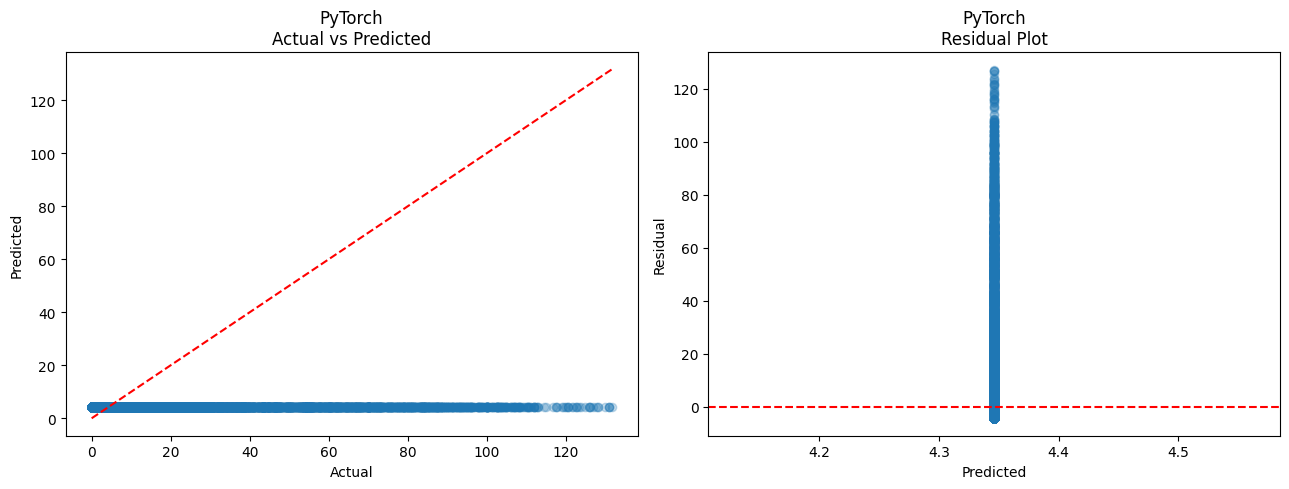

XGBoost
MAE                : 0.7653
MSE                : 6.0866
RMSE               : 2.4671
MAPE (%)           : 6604402620166500.00
Median AE          : 0.2314
Explained Variance : 0.9552
R²                 : 0.9552


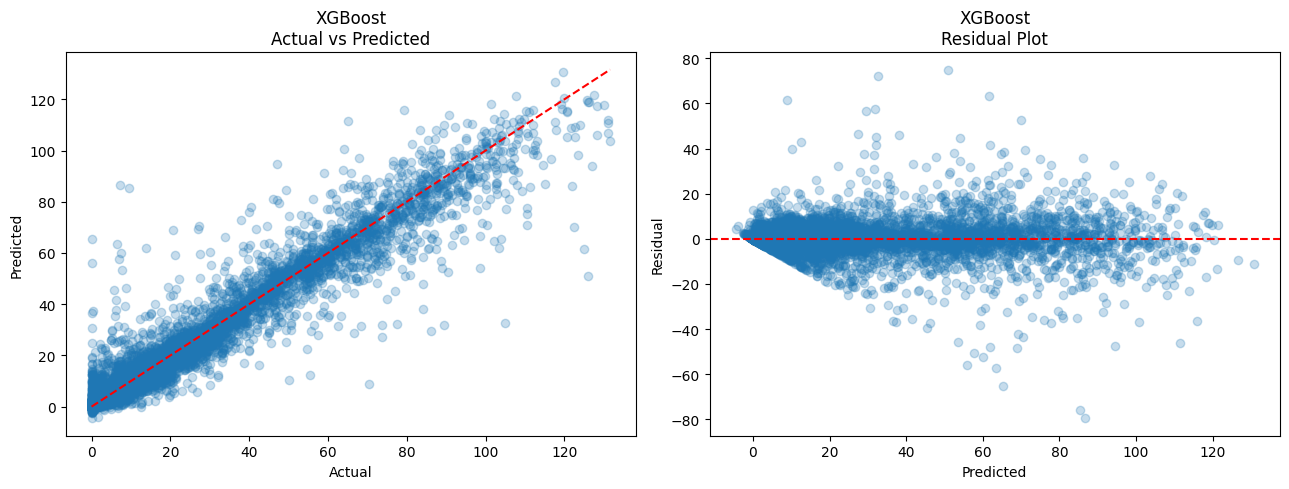

XGBoost Tuned
MAE                : 0.8486
MSE                : 6.4754
RMSE               : 2.5447
MAPE (%)           : 7029000888958710.00
Median AE          : 0.2814
Explained Variance : 0.9523
R²                 : 0.9523


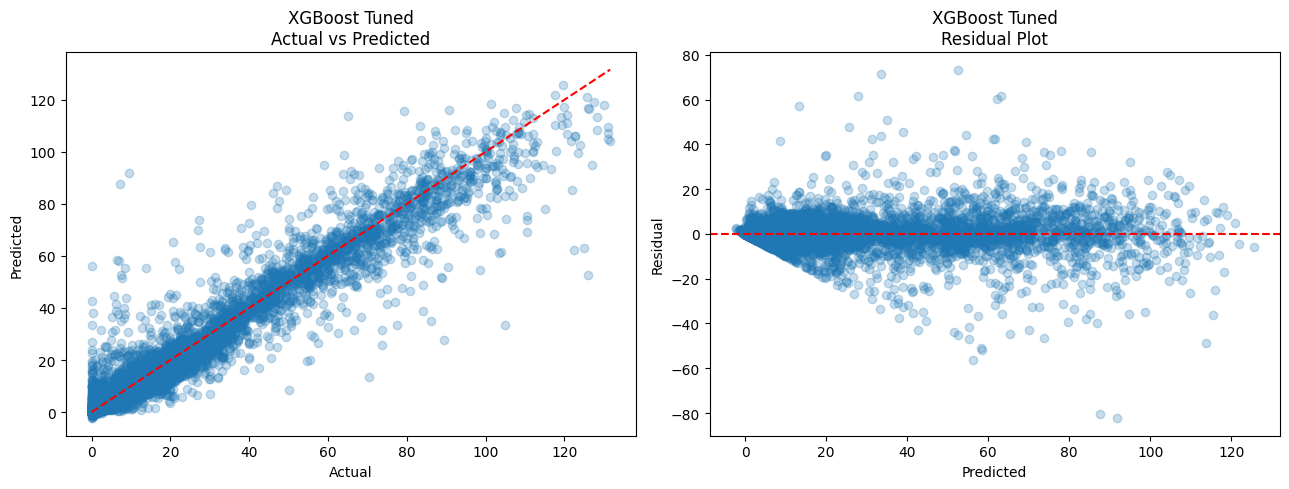

LightGBM
MAE                : 0.8603
MSE                : 6.5473
RMSE               : 2.5588
MAPE (%)           : 7706451305528014.00
Median AE          : 0.2870
Explained Variance : 0.9518
R²                 : 0.9518


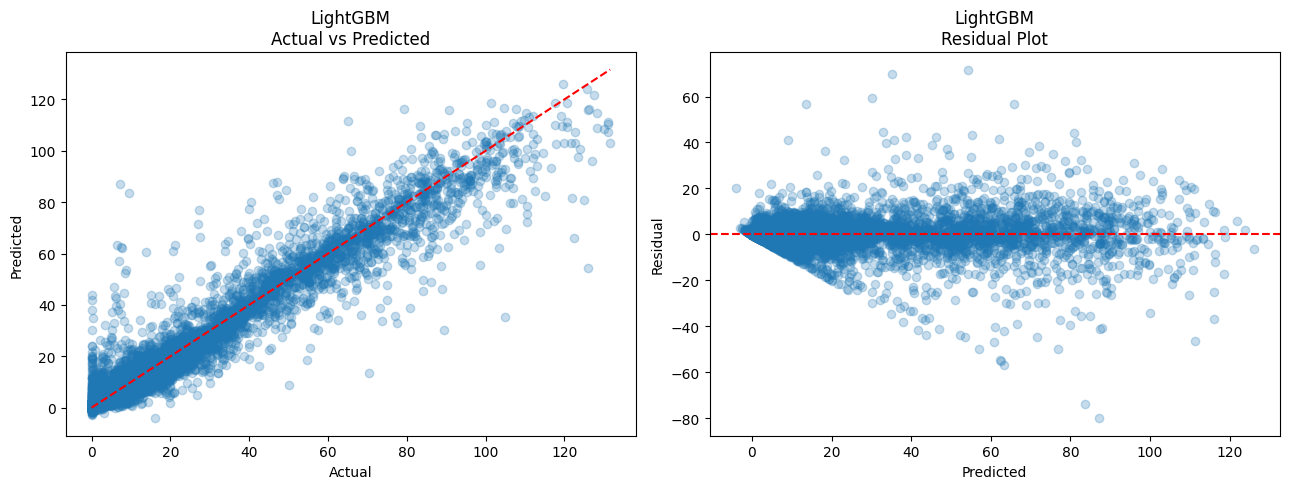

LightGBM Tuned
MAE                : 0.8298
MSE                : 5.8139
RMSE               : 2.4112
MAPE (%)           : 7544132960594059.00
Median AE          : 0.2905
Explained Variance : 0.9572
R²                 : 0.9572


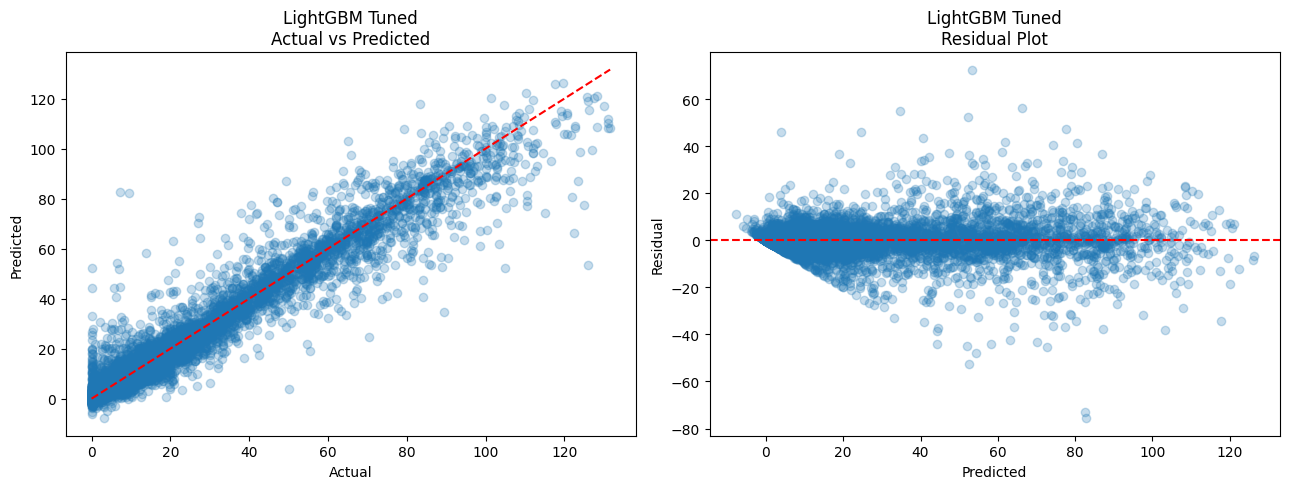

CatBoost
MAE                : 0.9920
MSE                : 8.4288
RMSE               : 2.9032
MAPE (%)           : 6504563270766709.00
Median AE          : 0.2844
Explained Variance : 0.9380
R²                 : 0.9380


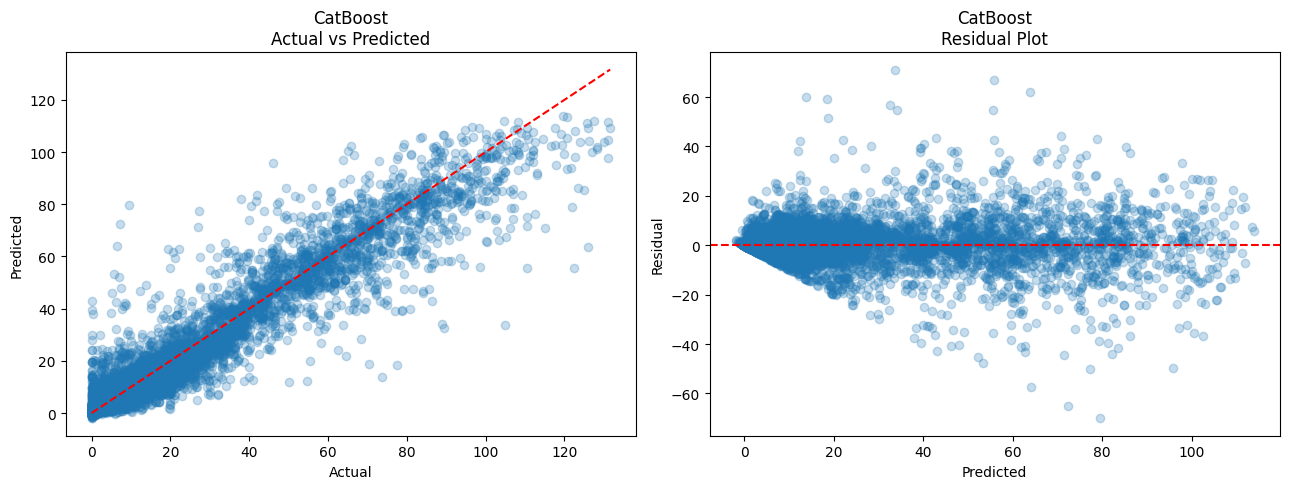

CatBoost Tuned
MAE                : 0.9136
MSE                : 7.3174
RMSE               : 2.7051
MAPE (%)           : 5583620161602205.00
Median AE          : 0.2723
Explained Variance : 0.9462
R²                 : 0.9461


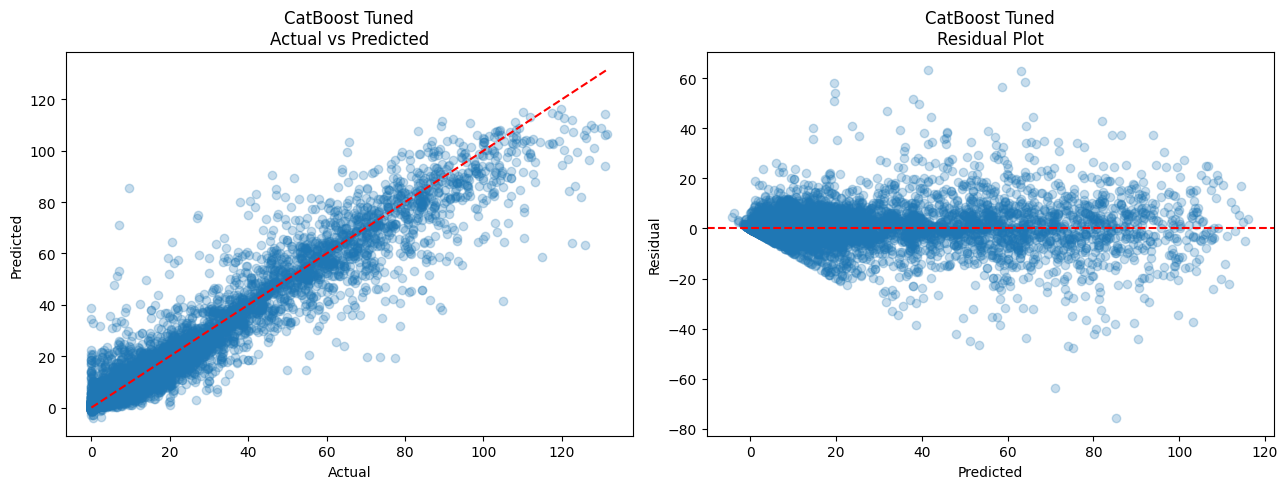

In [27]:
pytorch_metrics = evaluate_model(
    "PyTorch",
    true_labels,
    predictions
)

xgb_metrics = evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)

xgb_tuned_metrics = evaluate_model(
    "XGBoost Tuned",
    y_test,
    best_xgb_predictions
)

lgb_metrics = evaluate_model(
    "LightGBM",
    y_test,
    lgbm_predictions
)

lgb_tuned_metrics = evaluate_model(
    "LightGBM Tuned",
    y_test,
    best_lgbm_predictions
)

cat_metrics = evaluate_model(
    "CatBoost",
    y_test,
    catboost_predictions
)

cat_tuned_metrics = evaluate_model(
    "CatBoost Tuned",
    y_test,
    best_catboost_predictions
)

## 7.1 Final Comparision Table

In [48]:
comparison = pd.DataFrame([
    pytorch_metrics,
    xgb_metrics,
    xgb_tuned_metrics,
    lgb_metrics,
    lgb_tuned_metrics,
    cat_metrics,
    cat_tuned_metrics
])

comparison = comparison.sort_values(
    "R2",
    ascending=False
)

display(comparison)

comparison.to_csv(
    "results/model_comparison.csv",
    index=False
)

,Model,MAE,MSE,RMSE,MAPE,MedianAE,ExplainedVariance,R2
4,LightGBM Tuned,0.829771,5.813883,2.411200,7.544133e+15,0.290511,0.957211,0.957211
1,XGBoost,0.765310,6.086643,2.467112,6.604403e+15,0.231397,0.955203,0.955203
2,XGBoost Tuned,0.848590,6.475375,2.544676,7.029001e+15,0.281433,0.952342,0.952342
3,LightGBM,0.860349,6.547255,2.558761,7.706451e+15,0.287004,0.951813,0.951813
6,CatBoost Tuned,0.913640,7.317395,2.705068,5.583620e+15,0.272344,0.946153,0.946145
5,CatBoost,0.992043,8.428783,2.903237,6.504563e+15,0.284354,0.937973,0.937965
0,PyTorch,5.302983,135.872772,11.656448,1.907691e+16,3.500109,0.000000,-0.000002


# 8. Feature Importance Comparision

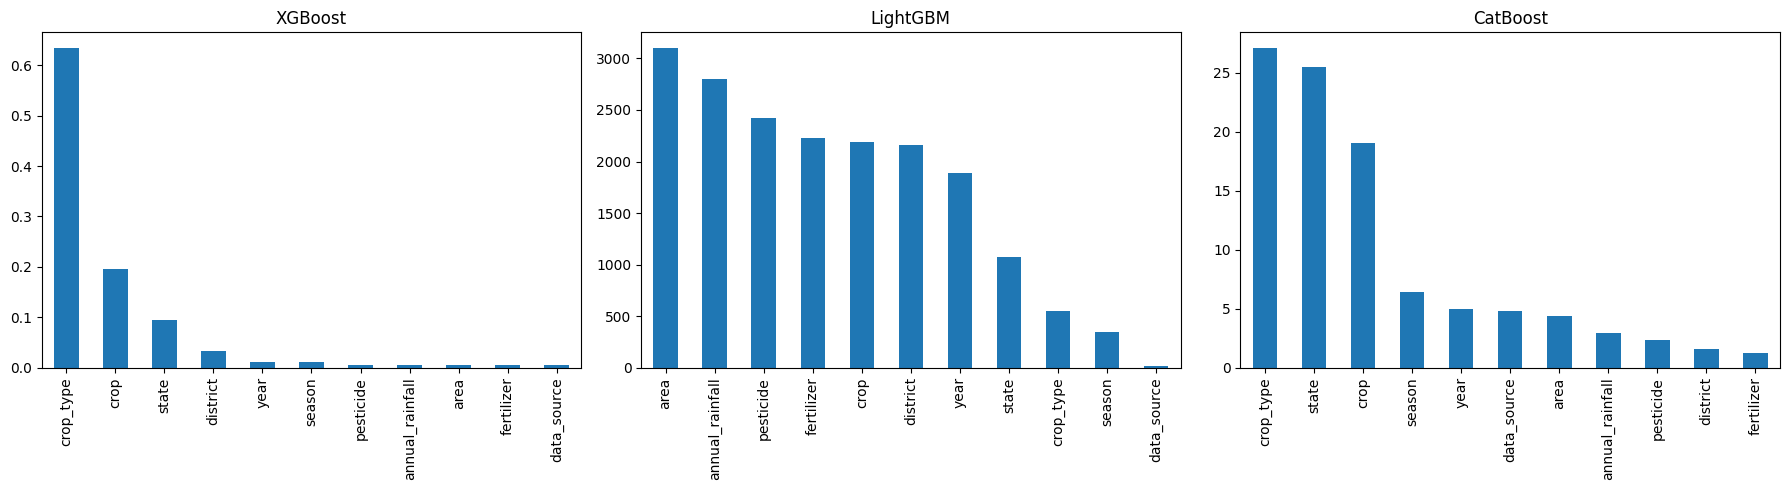

In [29]:
fig,ax=plt.subplots(1,3,figsize=(18,5))

pd.Series(
xgb_model.feature_importances_,
index=X_train.columns
).nlargest(15).plot.bar(ax=ax[0])

ax[0].set_title("XGBoost")

pd.Series(
best_lgbm_model.feature_importances_,
index=X_train.columns
).nlargest(15).plot.bar(ax=ax[1])

ax[1].set_title("LightGBM")

pd.Series(
best_catboost_model.get_feature_importance(),
index=X_train.columns
).nlargest(15).plot.bar(ax=ax[2])

ax[2].set_title("CatBoost")

plt.tight_layout()

# 9. Worst Predictions

In [58]:
best_preds=best_lgbm_predictions

errors=pd.DataFrame({

"Actual":y_test,

"Predicted":best_preds,

"Absolute Error":np.abs(y_test-best_preds)

})

errors=errors.sort_values(
"Absolute Error",
ascending=False
)

display(errors.head(25))

,Actual,Predicted,Absolute Error
336515,7.125506,82.780729,75.655223
42368,9.555556,82.436158,72.880603
69467,125.934211,53.386566,72.547645
45811,122.500000,66.324608,56.175392
168678,89.465154,34.629304,54.835850
146364,104.900731,52.372008,52.528724
235188,0.000000,52.451804,52.451804
93325,6.450909,54.236728,47.785819
17487,125.000000,77.577511,47.422489
399586,50.000000,3.789701,46.210299


# 10. Learnig Curves

## 10.1 XGBoost Learing Curve

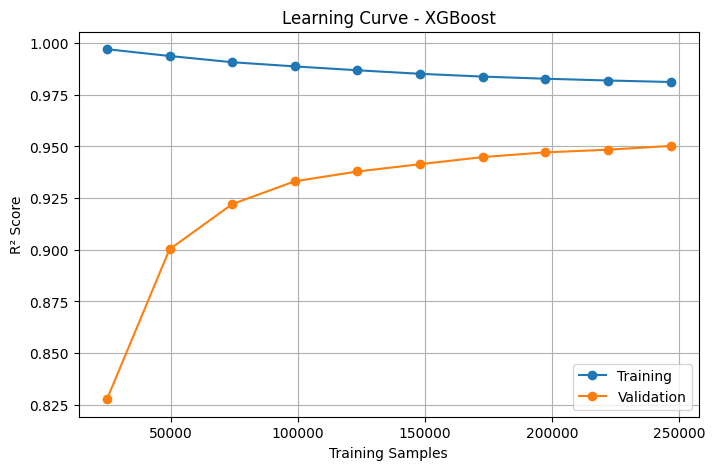

In [31]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_xgb_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training')
plt.plot(train_sizes, val_mean, marker='o', label='Validation')
plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve - XGBoost")
plt.grid(True)
plt.legend()
plt.show()

## 10.2 LightGBM Learing Curve

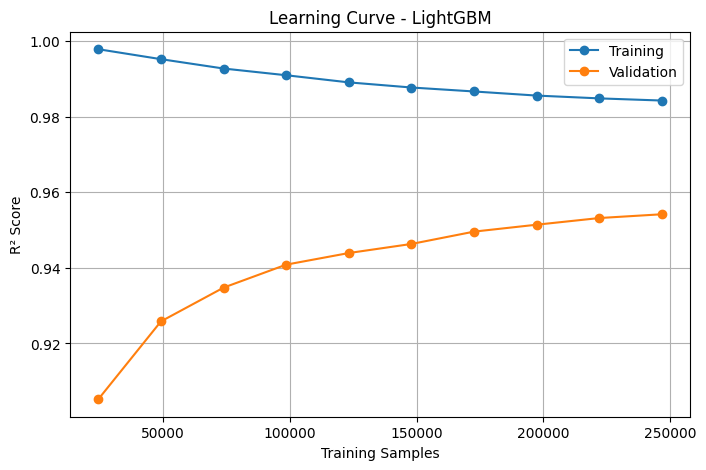

In [32]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_lgbm_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Training')
plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validation')
plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve - LightGBM")
plt.grid(True)
plt.legend()
plt.show()

## 10.3 CatBoost Learning Curve


# 11. SAVE ALL MODELS TO DISK

In [38]:
import os
import json
import joblib

os.makedirs("saved_models", exist_ok=True)

xgb_model.save_model("saved_models/xgboost_initial.json")
best_xgb_model.save_model("saved_models/xgboost_tuned.json")


lgbm_model.booster_.save_model("saved_models/lightgbm_initial.txt")
best_lgbm_model.booster_.save_model("saved_models/lightgbm_tuned.txt")


catboost_model.save_model("saved_models/catboost_initial.cbm")
best_catboost_model.save_model("saved_models/catboost_tuned.cbm")


torch.save(
    torch_model.state_dict(),
    "saved_models/pytorch_model.pth"
)

#joblib.dump(label_encoders, "saved_models/label_encoders.pkl")
#joblib.dump(feature_names, "saved_models/feature_names.pkl")

# Save scaler only if you actually used one
# joblib.dump(scaler, "saved_models/scaler.pkl")

# ---------------------------
# Display Model Sizes
# ---------------------------
model_sizes = {}

for file in os.listdir("saved_models"):

    path = os.path.join("saved_models", file)

    size_kb = os.path.getsize(path) / 1024

    model_sizes[file] = round(size_kb, 2)

print("="*60)
print("Saved Model Sizes")
print("="*60)

for name, size in sorted(model_sizes.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<35} {size:>8.2f} KB")

with open("saved_models/model_sizes.json", "w") as f:
    json.dump(model_sizes, f, indent=4)

print("\n✓ All models and preprocessing objects saved successfully.")

Saved Model Sizes
xgboost_initial.json                63789.12 KB
xgboost_tuned.json                  46479.03 KB
catboost_tuned.cbm                  20259.80 KB
catboost_initial.cbm                18837.00 KB
lightgbm_initial.txt                 3351.68 KB
lightgbm_tuned.txt                   1830.19 KB
pytorch_model.pth                    1088.66 KB

✓ All models and preprocessing objects saved successfully.



# 12. INFERENCE TIMING (per-model, for Computational Performance section)

In [39]:
print(type(X_test_tensor))
print(type(X_test))

<class 'torch.Tensor'>
<class 'pandas.core.frame.DataFrame'>


In [40]:
import os
import time
import numpy as np
import pandas as pd

os.makedirs("results", exist_ok=True)

timing_rows = []
n_repeats = 10

def time_predict(predict_fn, X, repeats=n_repeats):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        predict_fn(X)
        end = time.perf_counter()
        times.append(end - start)
    return np.mean(times), np.std(times)
# -------------------------
# PyTorch prediction wrapper
# -------------------------
def pytorch_predict(X_tensor):
    torch_model.eval()
    with torch.no_grad():
        return torch_model(X_tensor.to(device)).cpu().numpy()
        
timing_specs = [

    ("PyTorch", pytorch_predict, X_test_tensor),
    ("XGBoost (Initial)", xgb_model.predict, X_test),
    ("XGBoost (Tuned)", best_xgb_model.predict, X_test),
    ("LightGBM (Initial)", lgbm_model.predict, X_test),
    ("LightGBM (Tuned)", best_lgbm_model.predict, X_test),
    ("CatBoost (Initial)", catboost_model.predict, X_test),
    ("CatBoost (Tuned)", best_catboost_model.predict, X_test),
]

for name, predict_fn, X in timing_specs:
    mean_time, std_time = time_predict(predict_fn, X)
    timing_rows.append({
        "Model": name,
        "Inference Time (s)": round(mean_time, 6),
        "Inference Time (ms)": round(mean_time * 1000, 3),
        "Std (ms)": round(std_time * 1000, 3),
        "Rows/sec": round(len(X) / mean_time, 2)

    })

timing_table = pd.DataFrame(timing_rows)

timing_table = timing_table.sort_values(
    "Inference Time (ms)"
)

print("\nInference Performance\n")
print(timing_table.to_string(index=False))

timing_table.to_csv(
    "results/inference_timing.csv",
    index=False
)


Inference Performance

             Model  Inference Time (s)  Inference Time (ms)  Std (ms)  Rows/sec
CatBoost (Initial)            0.360472              360.472     8.529 177603.15
  CatBoost (Tuned)            0.388931              388.931    21.112 164607.73
           PyTorch            0.478607              478.607   251.724 133765.41
  LightGBM (Tuned)            1.024484             1024.484    18.052  62490.98
LightGBM (Initial)            2.197810             2197.810    39.590  29129.45
   XGBoost (Tuned)            3.277921             3277.921    91.874  19530.98
 XGBoost (Initial)            3.351613             3351.613    78.980  19101.55


# 13 SHAP Theory

In [ ]:
!pip install shap

## 13.1 Interpreting SHAP Plots

Generating SHAP values for the LGBMRegressor(colsample_bytree=np.float64(0.749816047538945), device='cpu',
              learning_rate=np.float64(0.2536999076681772), max_depth=12,
              min_child_samples=30, n_estimators=202, n_jobs=1, num_leaves=94,
              objective='regression', random_state=42,
              reg_alpha=np.float64(0.0019780827689353767),
              reg_lambda=np.float64(0.0004661686413912767),
              subsample=np.float64(0.6571467271687763), verbosity=-1) model...
SHAP values computed. Generating plots...


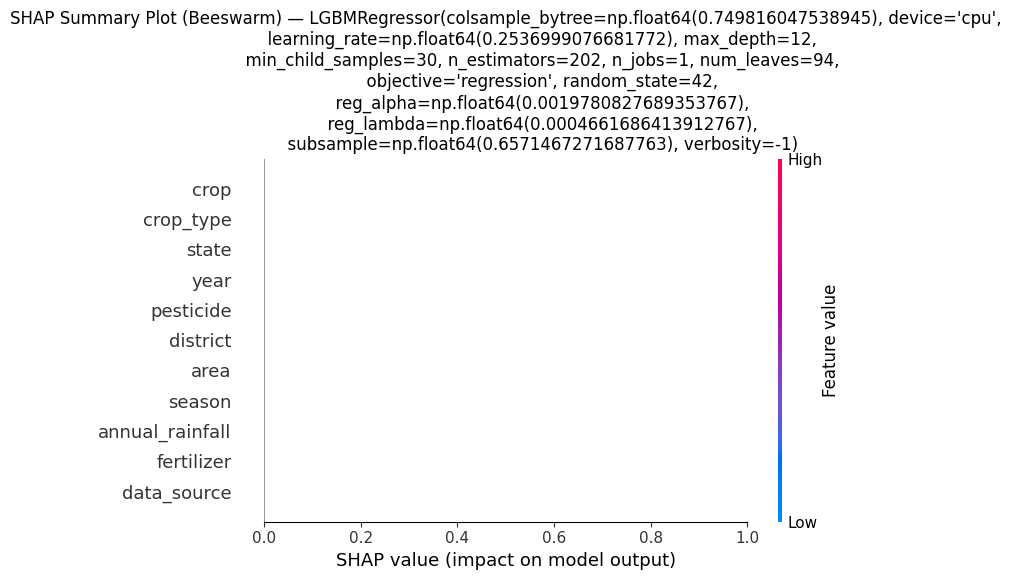

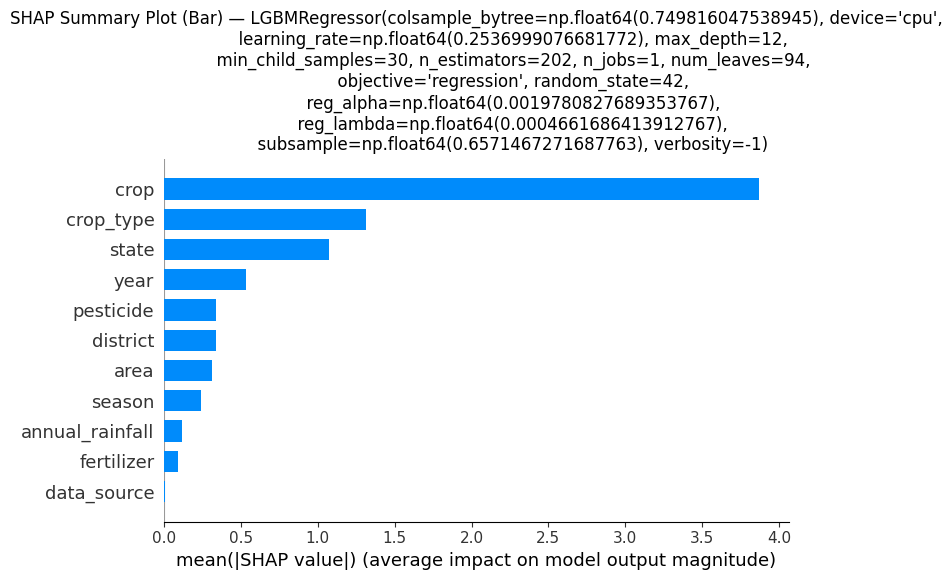

In [42]:
import shap
import matplotlib.pyplot as plt
best_model_name = best_lgbm_model
# Assuming best_lgbm_model is available from previous steps
# If not, you might need to load it again

print(f"Generating SHAP values for the {best_model_name} model...")

# Use a subset of the data for faster computation, if X_test is very large
# For better accuracy, use the full X_test if computation time allows
X_test_sampled = X_test.sample(min(1000, len(X_test)), random_state=42) # Sample 1000 instances or less

# Create a SHAP explainer for the LightGBM model
explainer = shap.TreeExplainer(best_lgbm_model)

# Calculate SHAP values for the sampled test data
shap_values = explainer.shap_values(X_test_sampled)

print("SHAP values computed. Generating plots...")

# 1. SHAP Summary Plot (beeswarm) - shows overall feature importance and impact direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sampled, plot_type="beeswarm", show=False)
plt.title(f'SHAP Summary Plot (Beeswarm) — {best_model_name}')
plt.tight_layout()
plt.savefig('shap_beeswarm_summary.png', dpi=150)
plt.show()

# 2. SHAP Summary Plot (bar) - shows average magnitude of feature impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sampled, plot_type="bar", show=False)
plt.title(f'SHAP Summary Plot (Bar) — {best_model_name}')
plt.tight_layout()
plt.savefig('shap_bar_summary.png', dpi=150)
plt.show()


## 13.2 PREDICTED VS ACTUAL + RESIDUAL PLOTS (best model)


In [49]:

best_preds = model_predictions[best_model_name]
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_preds, alpha=0.15, s=8)
lims = [0, max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual yield')
axes[0].set_ylabel('Predicted yield')
axes[0].set_title(f'Predicted vs Actual — {best_model_name}')

axes[1].scatter(best_preds, residuals, alpha=0.15, s=8)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted yield')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('predicted_vs_actual_residuals.png', dpi=150)
plt.show()

NameError: name 'model_predictions' is not defined

# 14. Hyperparameter Analysis Artifacts

In [50]:
import os
import json
import pandas as pd

os.makedirs("results", exist_ok=True)

# -----------------------------
# Save RandomizedSearchCV Results
# -----------------------------
pd.DataFrame(random_search.cv_results_).to_csv(
    "results/xgboost_cv_results.csv",
    index=False
)

pd.DataFrame(lgbm_random_search.cv_results_).to_csv(
    "results/lightgbm_cv_results.csv",
    index=False
)

pd.DataFrame(catboost_random_search.cv_results_).to_csv(
    "results/catboost_cv_results.csv",
    index=False
)

# -----------------------------
# Save Best Hyperparameters
# -----------------------------
best_params_summary = {
    "XGBoost": random_search.best_params_,
    "LightGBM": lgbm_random_search.best_params_,
    "CatBoost": catboost_random_search.best_params_,
}

# Convert NumPy types to Python types for JSON serialization
best_params_summary = {
    model: {
        key: value.item() if hasattr(value, "item") else value
        for key, value in params.items()
    }
    for model, params in best_params_summary.items()
}

with open("results/best_hyperparameters.json", "w") as f:
    json.dump(best_params_summary, f, indent=4)

print("=" * 60)
print("Hyperparameter Tuning Results Saved")
print("=" * 60)
print("✓ xgboost_cv_results.csv")
print("✓ lightgbm_cv_results.csv")
print("✓ catboost_cv_results.csv")
print("✓ best_hyperparameters.json")

Hyperparameter Tuning Results Saved
✓ xgboost_cv_results.csv
✓ lightgbm_cv_results.csv
✓ catboost_cv_results.csv
✓ best_hyperparameters.json


# 15. LOG-TRANSFORM TARGET SETUP

In [51]:

# yield is right-skewed and heteroscedastic across crop_type (sugar 0-130
# vs pulses 0-3). log1p compresses the scale so high-variance crops don't
# dominate the loss as much. log1p handles yield=0 rows correctly (log1p(0)=0).
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
# y_test stays on the ORIGINAL scale — we invert predictions back before
# scoring, so metrics stay comparable to your non-log models.

print("Original y_train range:", y_train.min(), "-", y_train.max())
print("Log y_train range:", y_train_log.min(), "-", y_train_log.max())

Original y_train range: 0.0 - 132.53274942878903
Log y_train range: 0.0 - 4.894346761829053


## 15.1 XGBOOST — LOG TARGET (reuses tuned hyperparameters from random_search)

In [52]:

xgb_log_params = dict(random_search.best_params_)  # reuse tuned hyperparams
xgb_model_log = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=30,
    eval_metric='rmse',
    **xgb_log_params
)
xgb_model_log.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=False)

xgb_log_preds = np.expm1(xgb_model_log.predict(X_test))  # invert back to real yield units
xgb_log_preds = np.clip(xgb_log_preds, 0, None)          # yield can't be negative

mse_xgb_log = mean_squared_error(y_test, xgb_log_preds)
rmse_xgb_log = np.sqrt(mse_xgb_log)
mae_xgb_log = mean_absolute_error(y_test, xgb_log_preds)
r2_xgb_log = r2_score(y_test, xgb_log_preds)

print(f"XGBoost (log-target) — MAE: {mae_xgb_log:.4f}  RMSE: {rmse_xgb_log:.4f}  R2: {r2_xgb_log:.4f}")

XGBoost (log-target) — MAE: 0.8674  RMSE: 2.9073  R2: 0.9378



## 15.2 LIGHTGBM — LOG TARGET

In [53]:

lgbm_log_params = dict(lgbm_random_search.best_params_)
lgbm_model_log = lgb.LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **lgbm_log_params
)
lgbm_model_log.fit(
    X_train, y_train_log,
    eval_set=[(X_val, y_val_log)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

lgbm_log_preds = np.expm1(lgbm_model_log.predict(X_test))
lgbm_log_preds = np.clip(lgbm_log_preds, 0, None)

mse_lgbm_log = mean_squared_error(y_test, lgbm_log_preds)
rmse_lgbm_log = np.sqrt(mse_lgbm_log)
mae_lgbm_log = mean_absolute_error(y_test, lgbm_log_preds)
r2_lgbm_log = r2_score(y_test, lgbm_log_preds)

print(f"LightGBM (log-target) — MAE: {mae_lgbm_log:.4f}  RMSE: {rmse_lgbm_log:.4f}  R2: {r2_lgbm_log:.4f}")

LightGBM (log-target) — MAE: 0.8045  RMSE: 2.8044  R2: 0.9421



## 15.3 CATBOOST — LOG TARGET


In [54]:

cb_log_params = dict(catboost_random_search.best_params_)
catboost_model_log = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    cat_features=tuple(cat_features_indices),
    random_seed=42,
    verbose=0,
    task_type='CPU',
    early_stopping_rounds=30,
    **cb_log_params
)
catboost_model_log.fit(X_train_cb, y_train_log, eval_set=(X_val_cb, y_val_log))

cb_log_preds = np.expm1(catboost_model_log.predict(X_test_cb))
cb_log_preds = np.clip(cb_log_preds, 0, None)

mse_cb_log = mean_squared_error(y_test, cb_log_preds)
rmse_cb_log = np.sqrt(mse_cb_log)
mae_cb_log = mean_absolute_error(y_test, cb_log_preds)
r2_cb_log = r2_score(y_test, cb_log_preds)

print(f"CatBoost (log-target) — MAE: {mae_cb_log:.4f}  RMSE: {rmse_cb_log:.4f}  R2: {r2_cb_log:.4f}")

CatBoost (log-target) — MAE: 0.8909  RMSE: 3.0615  R2: 0.9310



## 15.4 BEFORE / AFTER COMPARISON TABLE

In [55]:

comparison_rows = [
    {'Model': 'XGBoost (Tuned, original)',  'MAE': mean_absolute_error(y_test, best_xgb_predictions),  'RMSE': np.sqrt(mean_squared_error(y_test, best_xgb_predictions)),  'R2': r2_score(y_test, best_xgb_predictions)},
    {'Model': 'XGBoost (Tuned, log-target)', 'MAE': mae_xgb_log,  'RMSE': rmse_xgb_log,  'R2': r2_xgb_log},
    {'Model': 'LightGBM (Tuned, original)', 'MAE': mean_absolute_error(y_test, best_lgbm_predictions), 'RMSE': np.sqrt(mean_squared_error(y_test, best_lgbm_predictions)), 'R2': r2_score(y_test, best_lgbm_predictions)},
    {'Model': 'LightGBM (Tuned, log-target)', 'MAE': mae_lgbm_log, 'RMSE': rmse_lgbm_log, 'R2': r2_lgbm_log},
    {'Model': 'CatBoost (Tuned, original)', 'MAE': mean_absolute_error(y_test, best_catboost_predictions), 'RMSE': np.sqrt(mean_squared_error(y_test, best_catboost_predictions)), 'R2': r2_score(y_test, best_catboost_predictions)},
    {'Model': 'CatBoost (Tuned, log-target)', 'MAE': mae_cb_log, 'RMSE': rmse_cb_log, 'R2': r2_cb_log},
]
comparison_table = pd.DataFrame(comparison_rows)
print(comparison_table.to_string(index=False))
comparison_table.to_csv('results/log_transform_comparison.csv', index=False)

                       Model      MAE     RMSE       R2
   XGBoost (Tuned, original) 0.848590 2.544676 0.952342
 XGBoost (Tuned, log-target) 0.867358 2.907288 0.937792
  LightGBM (Tuned, original) 0.829771 2.411200 0.957211
LightGBM (Tuned, log-target) 0.804514 2.804354 0.942119
  CatBoost (Tuned, original) 0.913640 2.705068 0.946145
CatBoost (Tuned, log-target) 0.890864 3.061515 0.931017


In [56]:

def mape_by_crop_type(preds, label):
    tmp = X_test.copy()
    tmp['actual'] = y_test.values
    tmp['predicted'] = preds
    tmp['pct_error'] = np.abs(tmp['actual'] - tmp['predicted']) / tmp['actual'].replace(0, np.nan) * 100
    result = tmp.groupby('crop_type', observed=True)['pct_error'].mean().sort_values(ascending=False)
    result.name = label
    return result

# pick whichever tuned model performed best originally — swap in the right one
mape_original = mape_by_crop_type(best_catboost_predictions, 'Original')
mape_log = mape_by_crop_type(cb_log_preds, 'Log-target')

mape_compare = pd.concat([mape_original, mape_log], axis=1)
mape_compare['improvement (pp)'] = mape_compare['Original'] - mape_compare['Log-target']
print(mape_compare.sort_values('improvement (pp)', ascending=False))
mape_compare.to_csv('results/mape_log_vs_original_by_crop_type.csv')

                       Original  Log-target  improvement (pp)
crop_type                                                    
plantation crops     264.002690   69.291154        194.711536
fiber crops          557.029455  423.052518        133.976937
pulses               142.631977   92.180387         50.451590
fruits                99.261272   55.243811         44.017461
oilseeds             100.532303   58.399816         42.132487
spices                77.676912   44.517316         33.159596
vegetable             87.748213   56.106454         31.641760
drugs and narcotics   50.188535   30.674057         19.514478
cereals              118.191694   99.393827         18.797867
sugar                 35.347665   30.776255          4.571410


In [57]:
# Compress the directory into a zip archive
!zip -r output_files.zip /kaggle/working

# Generate an instant link to download the zip
from IPython.display import FileLink
FileLink(r'output_files.zip')


  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/shap_bar_summary.png (deflated 13%)
  adding: kaggle/working/catboost_info/ (stored 0%)
  adding: kaggle/working/catboost_info/test_error.tsv (deflated 56%)
  adding: kaggle/working/catboost_info/test/ (stored 0%)
  adding: kaggle/working/catboost_info/test/events.out.tfevents (deflated 73%)
  adding: kaggle/working/catboost_info/learn_error.tsv (deflated 55%)
  adding: kaggle/working/catboost_info/catboost_training.json (deflated 75%)
  adding: kaggle/working/catboost_info/tmp/ (stored 0%)
  adding: kaggle/working/catboost_info/time_left.tsv (deflated 50%)
  adding: kaggle/working/catboost_info/learn/ (stored 0%)
  adding: kaggle/working/catboost_info/learn/events.out.tfevents (deflated 73%)
  adding: kaggle/working/saved_models/ (stored 0%)
  adding: kaggle/working/saved_models/xgboost_tuned.json (deflated 90%)
  adding: kaggle/working/saved_models/xgboost_initial.json (deflated 89%)
  adding: kaggle/working/saved_models/

/kaggle/working/output_files.zip